# 4. الاستكشاف والتحليل التوضيحي المفصل - EDA (Exploratory Data Analysis)

In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3149.0,-23.574809,-46.587471,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813.0,-12.169860,-44.988369,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265.0,-16.746337,-48.514624,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,-5.767733,-35.275467,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9195.0,-23.675037,-46.524784,santo andre,SP,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       69608 non-null  object 
 1   customer_id                    69608 non-null  object 
 2   order_status                   69608 non-null  object 
 3   order_purchase_timestamp       69608 non-null  object 
 4   order_approved_at              69492 non-null  object 
 5   order_delivered_carrier_date   68373 non-null  object 
 6   order_delivered_customer_date  67533 non-null  object 
 7   order_estimated_delivery_date  69608 non-null  object 
 8   total_price                    69070 non-null  float64
 9   total_freight                  69070 non-null  float64
 10  total_items                    69070 non-null  float64
 11  total_weight_g                 69070 non-null  float64
 12  main_category                  68086 non-null 

In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       69608 non-null  object        
 1   customer_id                    69608 non-null  object        
 2   order_status                   69608 non-null  object        
 3   order_purchase_timestamp       69608 non-null  datetime64[ns]
 4   order_approved_at              69492 non-null  datetime64[ns]
 5   order_delivered_carrier_date   68373 non-null  datetime64[ns]
 6   order_delivered_customer_date  67533 non-null  datetime64[ns]
 7   order_estimated_delivery_date  69608 non-null  datetime64[ns]
 8   total_price                    69070 non-null  float64       
 9   total_freight                  69070 non-null  float64       
 10  total_items                    69070 non-null  float64       
 11  total_weight_g 

In [5]:
df.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  116
order_delivered_carrier_date      1235
order_delivered_customer_date     2075
order_estimated_delivery_date        0
total_price                        538
total_freight                      538
total_items                        538
total_weight_g                     538
main_category                     1522
seller_state                       538
total_payment                        1
max_installments                     1
review_id                          536
review_score                       536
review_comment_title             61474
review_comment_message           41006
review_creation_date               536
review_answer_timestamp            536
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state           

In [6]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,total_items,total_weight_g,total_payment,max_installments,review_score,customer_zip_code_prefix,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,is_late
count,69608,69492,68373,67533,69608,69070.000000,69070.000000,69070.000000,69070.000000,69607.000000,69607.000000,69072.000000,69608.000000,69407.000000,69407.000000,69407.000000,69608.000000
mean,2017-12-31 17:16:00.086699776,2018-01-01 03:37:22.819576320,2018-01-05 07:30:39.653050368,2018-01-14 21:47:59.230095104,2018-01-24 10:58:40.974600704,137.766874,22.836580,1.140770,2386.399117,161.034685,2.937406,4.084767,35165.526031,35082.967525,-21.189834,-46.168423,0.077922
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,2.290000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1003.000000,1003.000000,-36.605374,-72.666706,0.000000
25%,2017-09-12 17:48:35.249999872,2017-09-13 03:45:31.750000128,2017-09-18 16:13:17,2017-09-26 16:33:56,2017-10-03 00:00:00,45.900000,13.860000,1.000000,300.000000,62.010000,1.000000,4.000000,11443.000000,11432.000000,-23.588837,-48.097939,0.000000
50%,2018-01-19 10:19:27.500000,2018-01-19 16:02:55,2018-01-24 17:37:00,2018-02-02 22:51:49,2018-02-15 00:00:00,86.400000,17.170000,1.000000,750.000000,105.280000,2.000000,5.000000,24416.000000,24346.000000,-22.926905,-46.631748,0.000000
75%,2018-05-05 12:41:16,2018-05-05 15:10:36.750000128,2018-05-08 15:07:00,2018-05-16 17:19:18,2018-05-28 00:00:00,149.900000,24.030000,1.000000,2050.000000,176.705000,4.000000,5.000000,58840.000000,58328.000000,-20.146615,-43.586729,0.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-04 15:25:00,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1794.960000,15.000000,154200.000000,13664.080000,24.000000,5.000000,99990.000000,99990.000000,42.184003,-8.577855,1.000000
std,NaN,NaN,NaN,NaN,NaN,214.884703,21.946731,0.528917,4725.851833,226.149952,2.727340,1.347041,29783.417562,29768.537187,5.628715,4.067064,0.268051


In [7]:
df.select_dtypes(include=['object', 'category']).nunique()

order_id                   69608
customer_id                69608
order_status                   8
main_category                 71
seller_state                  23
review_id                  68827
review_comment_title        3405
review_comment_message     25567
review_creation_date         627
review_answer_timestamp    68753
customer_unique_id         67932
customer_city               3722
customer_state                27
geolocation_city            3815
geolocation_state             27
dtype: int64

In [8]:
df.groupby('seller_state')['is_late'].mean()

seller_state
AC    0.000000
AM    0.000000
BA    0.053708
CE    0.100000
DF    0.056940
ES    0.061135
GO    0.043344
MA    0.250000
MG    0.053965
MS    0.088235
MT    0.051020
PA    0.000000
PB    0.000000
PE    0.039711
PI    0.000000
PR    0.061854
RJ    0.078852
RN    0.128205
RO    0.000000
RS    0.042616
SC    0.060713
SE    0.000000
SP    0.085056
Name: is_late, dtype: float64

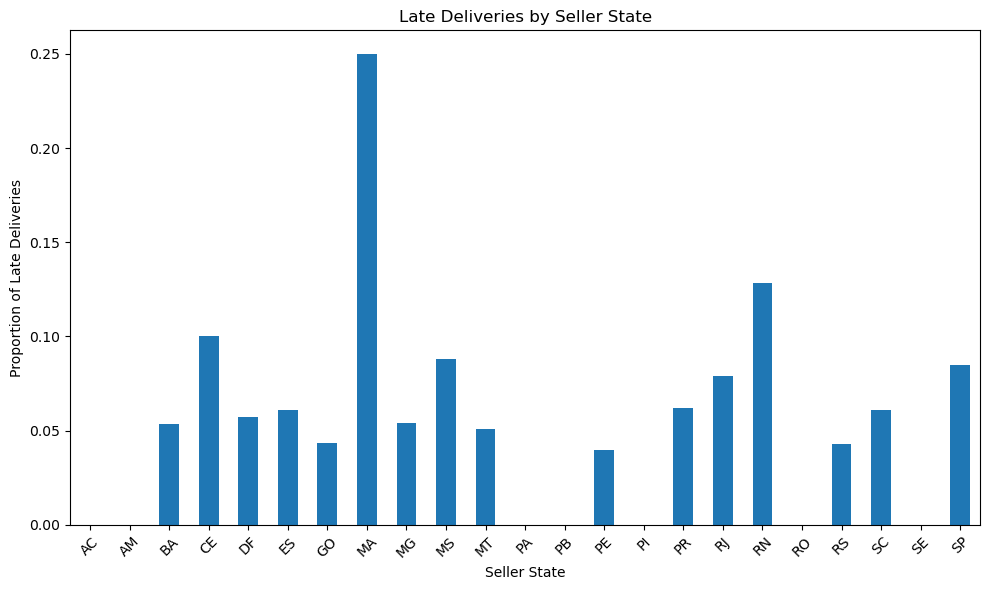

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.groupby('seller_state')['is_late'].mean().plot(kind='bar')
plt.xlabel('Seller State')
plt.ylabel('Proportion of Late Deliveries')
plt.title('Late Deliveries by Seller State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df.duplicated().sum()

0

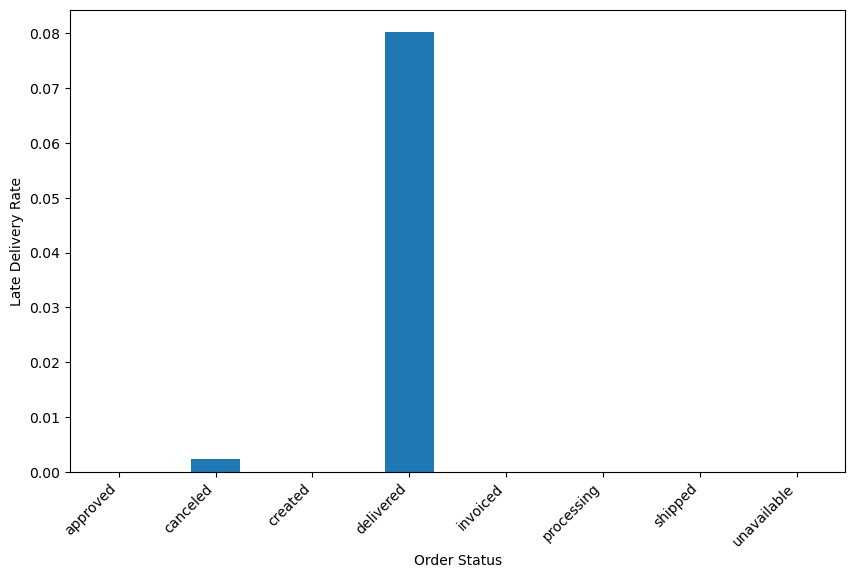

In [11]:
plt.figure(figsize=(10, 6))
df.groupby('order_status')['is_late'].mean().plot(kind='bar')
plt.xlabel('Order Status')
plt.xticks(rotation=45, ha='right') 
plt.ylabel('Late Delivery Rate')  
plt.show()

#نسبة الطلبات المتاخرة بالنسبة لحالة الطلب 



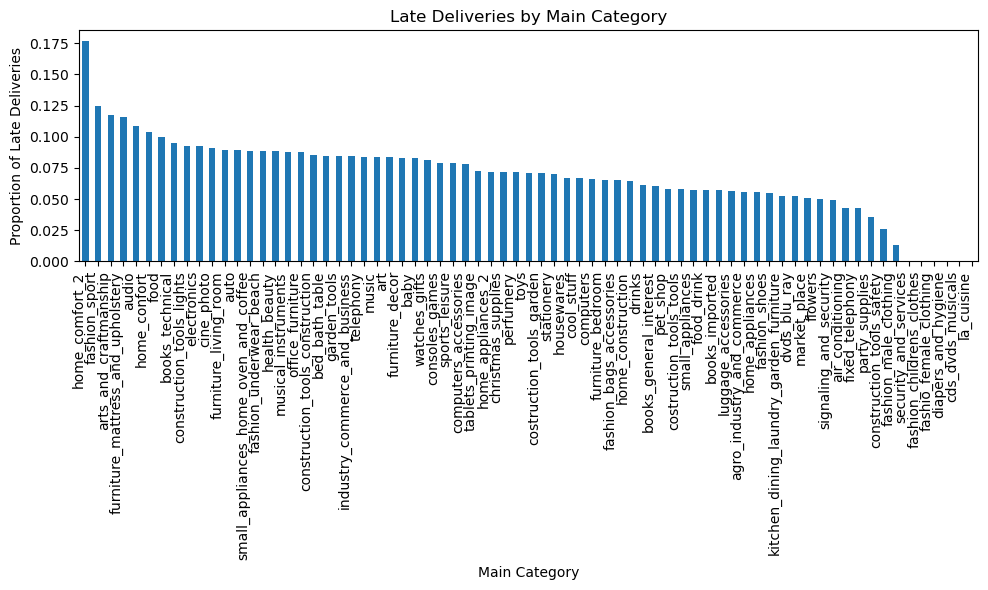

In [12]:
plt.figure(figsize=(10, 6))
df.groupby('main_category')['is_late'].mean().sort_values(ascending=False).plot(kind='bar')
plt.xlabel('Main Category')
plt.ylabel('Proportion of Late Deliveries')
plt.title('Late Deliveries by Main Category')
plt.tight_layout()
plt.xticks(rotation=90, ha='right')
plt.show()

Text(0.5, 1.0, 'Late Deliveries by Customer State')

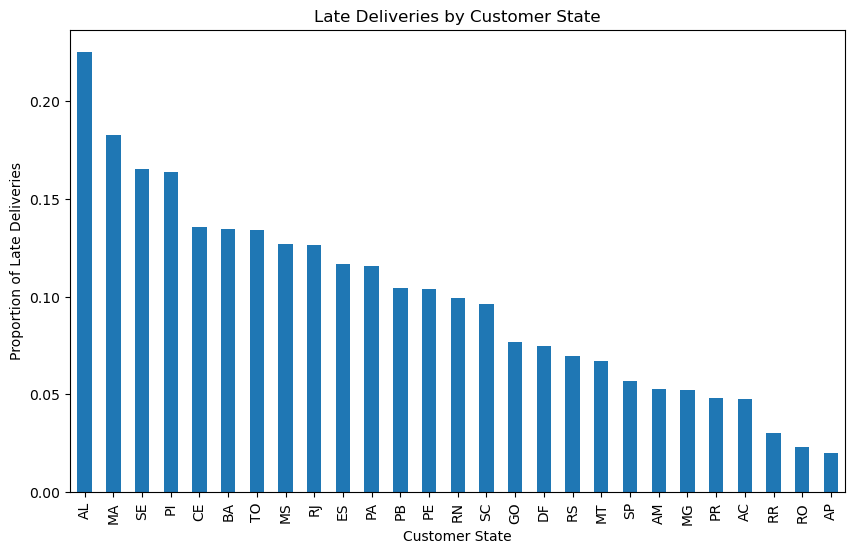

In [13]:
plt.figure(figsize=(10, 6))
df.groupby('customer_state')['is_late'].mean().sort_values(ascending=False).abs().plot(kind='bar')
plt.xlabel('Customer State')
plt.ylabel('Proportion of Late Deliveries')
plt.title('Late Deliveries by Customer State')


In [14]:
pd.crosstab(df['order_status'], df['is_late'], normalize='index') * 100

is_late,0,1
order_status,,
approved,100.000000,0.000000
canceled,99.774266,0.225734
created,100.000000,0.000000
delivered,91.969733,8.030267
invoiced,100.000000,0.000000
processing,100.000000,0.000000
shipped,100.000000,0.000000
unavailable,100.000000,0.000000


In [15]:
pd.crosstab(df['customer_state'], df['is_late'], normalize='index') * 100

is_late,0,1
customer_state,,
AC,95.238095,4.761905
AL,77.464789,22.535211
AM,94.736842,5.263158
AP,98.000000,2.000000
BA,86.530442,13.469558
CE,86.449580,13.550420
DF,92.506812,7.493188
ES,88.301621,11.698379
GO,92.329545,7.670455


In [16]:
c = pd.crosstab(df['main_category'], df['is_late'], normalize='index') * 100 
c.sort_values(by=1,ascending=False)

is_late,0,1
main_category,,
home_comfort_2,82.352941,17.647059
fashion_sport,87.500000,12.500000
arts_and_craftmanship,88.235294,11.764706
furniture_mattress_and_upholstery,88.461538,11.538462
audio,89.130435,10.869565
...,...,...
fashion_childrens_clothes,100.000000,0.000000
fashio_female_clothing,100.000000,0.000000
diapers_and_hygiene,100.000000,0.000000


In [17]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3149.0,-23.574809,-46.587471,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,47813.0,-12.169860,-44.988369,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,75265.0,-16.746337,-48.514624,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,59296.0,-5.767733,-35.275467,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,9195.0,-23.675037,-46.524784,santo andre,SP,0


In [18]:
diff_days = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

print(diff_days.max())

205.0


In [19]:
## الفرق مش منطقي ^_^

In [20]:
diff_days.sort_values(ascending=False).head(30)

55620    205.0
19590    195.0
61611    188.0
54481    187.0
68770    182.0
62287    182.0
38509    181.0
31229    181.0
25883    178.0
66407    178.0
64489    172.0
40847    171.0
69172    167.0
37973    166.0
49985    165.0
29519    162.0
29265    162.0
11399    157.0
16945    145.0
47901    143.0
64738    138.0
46962    136.0
18731    134.0
3202     132.0
39624    132.0
56636    132.0
34262    130.0
4667     129.0
12813    128.0
28331    127.0
dtype: float64

In [21]:
pd.set_option('display.max_columns', None)


In [22]:
dorder_dirv = df[(df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days > 150][['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date', 'customer_state', 'main_category']]

dorder_dirv 

,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,main_category
11399,47b40429ed8cce3aee9199792275433f,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,SP,home_construction
19590,ca07593549f1816d26a572e06dc1eab6,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,ES,auto
25883,7c48bb55e8e4f7e56d412e9653db37bc,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,SP,books_technical
29265,6e6527028de694ccade37f5a15a6d84a,2017-11-28 17:11:21,2018-05-10 00:06:20,2017-12-18,RJ,garden_tools
29519,4fbc8d6f2f4db3e789d5a876fa349b56,2018-02-08 01:04:18,2018-07-20 23:37:50,2018-03-08,MA,watches_gifts
31229,dfe5f68118c2576143240b8d78e5940a,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,RS,office_furniture
37973,df6d8b7768a047c2981bae0a24afbb01,2017-04-05 15:24:20,2017-09-19 15:08:19,2017-05-10,CE,computers_accessories
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,PI,watches_gifts
40847,d24e8541128cea179a11a65176e0a96f,2017-06-16 14:44:37,2017-12-04 18:36:29,2017-06-26,SP,housewares
49985,031e7d4e559a1bf08e71a419aa998d0a,2017-04-07 12:43:24,2017-09-19 16:23:52,2017-05-19,PE,telephony


In [23]:
dorder_dirv.sort_values(by='customer_state', ascending=False)

,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,main_category
11399,47b40429ed8cce3aee9199792275433f,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,SP,home_construction
25883,7c48bb55e8e4f7e56d412e9653db37bc,2018-01-26 13:35:00,2018-07-23 20:04:45,2018-08-07,SP,books_technical
40847,d24e8541128cea179a11a65176e0a96f,2017-06-16 14:44:37,2017-12-04 18:36:29,2017-06-26,SP,housewares
54481,2d7561026d542c8dbd8f0daeadf67a43,2017-03-16 09:29:16,2017-09-19 14:38:18,2017-04-13,SE,auto
31229,dfe5f68118c2576143240b8d78e5940a,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,RS,office_furniture
64489,3566eabb132f8d64741ae7b921bbd10e,2017-03-30 16:09:39,2017-09-19 15:07:09,2017-05-05,RN,home_confort
29265,6e6527028de694ccade37f5a15a6d84a,2017-11-28 17:11:21,2018-05-10 00:06:20,2017-12-18,RJ,garden_tools
55620,1b3190b2dfa9d789e1f14c05b647a14a,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,RJ,cool_stuff
38509,0f4519c5f1c541ddec9f21b3bddd533a,2017-03-22 05:28:14,2017-09-19 14:38:21,2017-04-11,PI,watches_gifts
49985,031e7d4e559a1bf08e71a419aa998d0a,2017-04-07 12:43:24,2017-09-19 16:23:52,2017-05-19,PE,telephony


In [24]:
diff_days.describe()

count    67533.000000
mean         8.859269
std          8.737122
min        -17.000000
25%          4.000000
50%          7.000000
75%         12.000000
max        205.000000
dtype: float64

In [25]:
dorder_dirv2 = df[(df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days > 12][['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date', 'customer_state', 'main_category']]

dorder_dirv2

,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,main_category
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,PR,auto
16,403b97836b0c04a622354cf531062e5f,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,RJ,construction_tools_construction
19,83018ec114eee8641c97e08f7b4e926f,2017-10-26 21:46:53,2017-11-08 22:22:00,2017-11-23,BA,telephony
25,fbf9ac61453ac646ce8ad9783d7d0af6,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,RJ,cool_stuff
29,ecab90c9933c58908d3d6add7c6f5ae3,2018-02-26 22:28:50,2018-03-27 23:29:14,2018-04-13,RR,garden_tools
...,...,...,...,...,...,...
69587,905c3d04fa7c2003ae6931a5ab967ad1,2017-06-26 14:40:10,2017-07-19 17:47:36,2017-07-28,PA,home_appliances
69589,a79cb797abc143a743a29342947938f1,2017-11-28 20:54:49,2017-12-12 19:38:42,2017-12-19,PR,garden_tools
69591,ec38e40a750810e337a528576f0090e7,2017-09-11 21:25:38,2017-10-11 14:17:03,2017-10-05,BA,bed_bath_table
69595,39c438f2a835b25cd51bbd1bed5d089e,2017-12-19 23:47:16,2018-01-08 17:15:47,2018-01-15,SP,computers_accessories


يُظهر التحليل الإحصائي أن الرباعي الثالث (75%) لمدد التوصيل يبلغ 12 يوماً، مما يعني أن معظم الطلبات تُسلم ضمن هذه الفترة.

تم رصد 14,780 طلباً تجاوزت مدة توصيلها 12 يوماً، وصولاً إلى حد أقصى بلغ 205 أيام، وهي تمثل القيم المتطرفة (Outliers) التي سيتم التعامل معها في مرحلة تنظيف البيانات

In [26]:
dorder_dirv3 = df[(df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days < 0][['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date', 'customer_state', 'main_category']]

dorder_dirv3
#هناك حالات يكون فيها تاريخ التسليم الفعلي قبل تاريخ الشحن، وهذا مستحيل واقعياً.

,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,main_category
6438,a1abeb653a4d4cd1e142ccb8c82cd069,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14,SP,furniture_decor
9554,383aa8b2724fe452d9ccd9934a8c628b,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21,MG,furniture_decor
13487,cb1134f9010d242e9515ad1c78ec0c39,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08,SP,furniture_decor
14474,dceb62e8fa94b46006c9554fed743df0,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11,MG,bed_bath_table
19268,5f9d46795c3126674e52becb3a1a517f,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31,SP,pet_shop
21338,8c78d01de3a9009e23d6877a7cc9be20,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30,SP,furniture_decor
22520,b27af682321527a6349f1761eb3f360c,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14,SP,home_confort
25393,1cc3ae63caffff2d6c3ee3e78e074acf,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25,SP,toys
25646,e37f11cae9985ca58f0b56f268720537,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24,SC,housewares
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18,SP,furniture_decor


In [27]:
dorder_dirv4 = df[(df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days == 0][['order_id', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date', 'customer_state','seller_state', 'main_category']]

dorder_dirv4.sample(20)
#الطلبات التي استغرقت 0 أيام تعود غالباً لوجود البائع والزبون في نفس الولاية (مثل SP)، وهو أمر منطقي بسبب تقارب المسافة

,order_id,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_state,seller_state,main_category
6039,13b4a241ec0a12dc277733bf73327633,2018-04-02 22:52:12,2018-04-03 15:29:03,2018-04-11,MG,MG,sports_leisure
64286,5f5009f6c5e45b305e8cab76a5df6a18,2017-06-01 14:36:20,2017-06-02 09:51:42,2017-06-14,SP,SP,health_beauty
4213,f20ea43e9a47fc54e94b12d3de6bfefe,2017-06-22 15:28:29,2017-06-23 10:59:32,2017-06-30,SP,SP,auto
7273,11e6a7d393dd5ce464e500e3f7264c05,2018-02-26 16:23:47,2018-02-27 16:08:03,2018-03-06,SP,SP,tablets_printing_image
7469,bf5c20ebc5a7b05e2efd6ecb0e4f7b62,2018-01-15 18:46:56,2018-01-16 14:40:18,2018-01-30,SP,SP,computers_accessories
3760,8176c11ca059602f1a7b1615f4cebbd6,2017-05-18 16:28:07,2017-05-19 10:38:08,2017-05-31,SP,SP,bed_bath_table
40038,65a73d6e115832b01eb4de0056cafa9d,2018-05-03 15:50:00,2018-05-04 14:16:53,2018-05-16,SP,SP,housewares
61950,ef442e129f56ec1234a402fc824686df,2018-07-03 06:58:00,2018-07-04 00:38:37,2018-07-20,SP,SP,computers
56060,edd810dc89c1eed484c29e04e184e8cf,2018-03-01 00:04:57,2018-03-01 17:22:13,2018-03-13,SP,SP,watches_gifts
64363,d69964b656a7ccf534ecca1716e557c1,2017-07-13 17:11:47,2017-07-14 17:09:48,2017-07-24,SP,SP,sports_leisure


In [28]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,total_items,total_weight_g,total_payment,max_installments,review_score,customer_zip_code_prefix,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,is_late
count,69608,69492,68373,67533,69608,69070.000000,69070.000000,69070.000000,69070.000000,69607.000000,69607.000000,69072.000000,69608.000000,69407.000000,69407.000000,69407.000000,69608.000000
mean,2017-12-31 17:16:00.086699776,2018-01-01 03:37:22.819576320,2018-01-05 07:30:39.653050368,2018-01-14 21:47:59.230095104,2018-01-24 10:58:40.974600704,137.766874,22.836580,1.140770,2386.399117,161.034685,2.937406,4.084767,35165.526031,35082.967525,-21.189834,-46.168423,0.077922
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,2.290000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1003.000000,1003.000000,-36.605374,-72.666706,0.000000
25%,2017-09-12 17:48:35.249999872,2017-09-13 03:45:31.750000128,2017-09-18 16:13:17,2017-09-26 16:33:56,2017-10-03 00:00:00,45.900000,13.860000,1.000000,300.000000,62.010000,1.000000,4.000000,11443.000000,11432.000000,-23.588837,-48.097939,0.000000
50%,2018-01-19 10:19:27.500000,2018-01-19 16:02:55,2018-01-24 17:37:00,2018-02-02 22:51:49,2018-02-15 00:00:00,86.400000,17.170000,1.000000,750.000000,105.280000,2.000000,5.000000,24416.000000,24346.000000,-22.926905,-46.631748,0.000000
75%,2018-05-05 12:41:16,2018-05-05 15:10:36.750000128,2018-05-08 15:07:00,2018-05-16 17:19:18,2018-05-28 00:00:00,149.900000,24.030000,1.000000,2050.000000,176.705000,4.000000,5.000000,58840.000000,58328.000000,-20.146615,-43.586729,0.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-04 15:25:00,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1794.960000,15.000000,154200.000000,13664.080000,24.000000,5.000000,99990.000000,99990.000000,42.184003,-8.577855,1.000000
std,NaN,NaN,NaN,NaN,NaN,214.884703,21.946731,0.528917,4725.851833,226.149952,2.727340,1.347041,29783.417562,29768.537187,5.628715,4.067064,0.268051


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69608 entries, 0 to 69607
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       69608 non-null  object        
 1   customer_id                    69608 non-null  object        
 2   order_status                   69608 non-null  object        
 3   order_purchase_timestamp       69608 non-null  datetime64[ns]
 4   order_approved_at              69492 non-null  datetime64[ns]
 5   order_delivered_carrier_date   68373 non-null  datetime64[ns]
 6   order_delivered_customer_date  67533 non-null  datetime64[ns]
 7   order_estimated_delivery_date  69608 non-null  datetime64[ns]
 8   total_price                    69070 non-null  float64       
 9   total_freight                  69070 non-null  float64       
 10  total_items                    69070 non-null  float64       
 11  total_weight_g 

In [30]:
# استخراج السنة من عمود تاريخ الشراء
df['order_year'] = df['order_purchase_timestamp'].dt.year

# حساب عدد الطلبات ونسبة التأخير لكل سنة
yearly_analysis = df.groupby('order_year').agg(
    total_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
)
print(yearly_analysis)

            total_orders  late_rate
order_year                         
2016                 228   0.013158
2017               31521   0.063133
2018               37859   0.090626


In [31]:
# فلترة بيانات سنة 2016 لوحدها
df_2016 = df[df['order_purchase_timestamp'].dt.year == 2016]

# فلترة بيانات سنة 2017 لوحدها
df_2017 = df[df['order_purchase_timestamp'].dt.year == 2017]

# فلترة بيانات سنة 2018 لوحدها
df_2018 = df[df['order_purchase_timestamp'].dt.year == 2018]

In [32]:
df_2016

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,total_items,total_weight_g,main_category,seller_state,total_payment,max_installments,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,is_late,order_year
324,d3c8851a6651eeff2f73b0e011ac45d0,957f8e082185574de25992dc659ebbc0,processing,2016-10-05 22:44:13,2016-10-06 15:51:05,NaT,NaT,2016-12-09,267.00,32.84,1.0,1900.0,books_technical,AC,299.84,1.0,160850927a5f16f903dc83a05e0a5826,1.0,NaN,NaN,2016-12-11 00:00:00,2016-12-13 10:17:32,07d5b1f9bdd053347f0213187b343ac9,3531,sao paulo,SP,3531.0,-23.540513,-46.517681,sao paulo,SP,0,2016
378,cbbb524a0e1646aa6cf7a3c0bbe517ad,dacb079d55ffb1d3955c5d923df3ebb7,delivered,2016-10-05 07:31:49,2016-10-06 02:46:24,2016-10-10 02:46:24,2016-10-16 14:36:00,2016-12-07,75.00,20.58,1.0,250.0,computers_accessories,MG,95.58,1.0,6f97d8b5afaf78f8658cfc0634840b40,1.0,NaN,produto entregue diferente do que foi comprado...,2016-10-21 00:00:00,2016-10-22 10:10:28,12cc890391e57d7123e004856ff1f137,50090,recife,PE,50090.0,-8.073396,-34.899768,recife,PE,0,2016
699,ac2b7c522d811acba0aa270ed3e112e4,ef21aebbb093a6db29ccc6aa0b89c347,delivered,2016-10-05 15:08:00,2016-10-06 15:44:26,2016-10-10 15:44:27,2016-10-13 15:44:27,2016-11-29,294.90,20.34,1.0,795.0,auto,PR,315.24,10.0,efef5a00aac989951350619e06681dcb,1.0,NaN,"Loja lixo, entregaram produto errado, mandei e...",2016-10-22 00:00:00,2016-10-24 23:33:19,664f7107c351f24b16b68919398730a0,13610,leme,SP,13610.0,-22.188011,-47.388910,leme,SP,0,2016
1384,7033745709b7cf1bac7d2533663592de,7f0ca17bb33b230b47459437cf0682c7,delivered,2016-10-04 14:13:22,2016-10-04 14:46:48,2016-10-08 14:46:49,2016-10-11 14:46:49,2016-11-30,93.90,17.61,1.0,1200.0,furniture_decor,PR,111.51,4.0,a0ba97ce98f76cf57bb2c5530513be70,3.0,NaN,dentro do anunciado.,2016-10-25 00:00:00,2016-10-26 23:52:15,1dc848c11c2985635c268ff3dea707eb,21853,rio de janeiro,RJ,21853.0,-22.869088,-43.506232,rio de janeiro,RJ,0,2016
1449,5cd498954e2b37d71b315166809b4bd7,ff1a56726b7ea149c7423865609cc0c8,delivered,2016-10-07 00:54:40,2016-10-08 03:56:15,2016-10-25 11:35:52,2016-10-27 17:32:07,2016-12-01,134.70,46.89,3.0,2400.0,perfumery,SP,181.59,1.0,d565a7363d2e9836a02775db90e54f3d,1.0,NaN,"Estou aguardando o restante da entrega, compre...",2016-10-27 00:00:00,2016-10-27 10:41:59,fb48b86d9a78b53675c121e4ec8981ed,21220,rio de janeiro,RJ,21220.0,-22.856731,-43.305178,rio de janeiro,RJ,0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68625,021d08e4057e5b6414c8d2f69f4f72a0,7470a1ddb5f78a811fbef15b2556781b,delivered,2016-10-07 17:37:49,2016-10-07 18:01:40,2016-10-25 12:05:58,2016-10-30 01:25:57,2016-12-19,51.50,14.53,1.0,100.0,auto,SP,66.03,1.0,00e927398b7a872a23c8990b38b7026a,1.0,NaN,Comprei o produto chave canivete para Logan. M...,2016-10-31 00:00:00,2016-11-02 12:04:41,5d2db05a565eda438cf5069b7be6b1bb,35400,ouro preto,MG,35400.0,-20.385237,-43.505513,ouro preto,MG,0,2016
68641,90bd4466c2905d7b5b56370149e62bcc,f11278c6a8edfe30db8bb9506ecbdff2,delivered,2016-10-09 11:33:12,2016-10-10 00:22:44,2016-10-15 10:09:46,2016-10-21 21:17:53,2016-12-06,35.00,16.05,1.0,250.0,computers_accessories,SP,51.05,1.0,2961357aed5485e126a05fc91fa8e9f3,4.0,NaN,Recomendo este vendedor.,2016-10-22 00:00:00,2016-10-22 21:10:00,1881f0742867dc75d6e0bcc24f866710,98290,condor,RS,98290.0,-28.205663,-53.482964,condor,RS,0,2016
68805,de8f4a82099fe4fa6bcb8952ca51420f,13db9c37d449305364a897e44f479406,delivered,2016-10-10 16:00:30,2016-10-10 16:43:18,2016-10-14 16:43:19,2016-10-17 17:43:19,2016-12-14,39.99,24.84,1.0,550.0,sports_leisure,PR,64.83,6.0,73a800e5

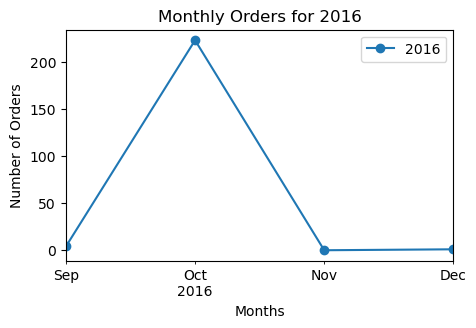

In [33]:
plt.figure(figsize=(5, 3))

# تجميع الطلبات حسب الشهر لـ 2016 وحساب عددها
df_2016.set_index('order_purchase_timestamp').resample('M')['order_id'].count().plot(kind='line', marker='o', label='2016')

plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders for 2016')
plt.legend()
plt.xticks(rotation=45)
plt.show()


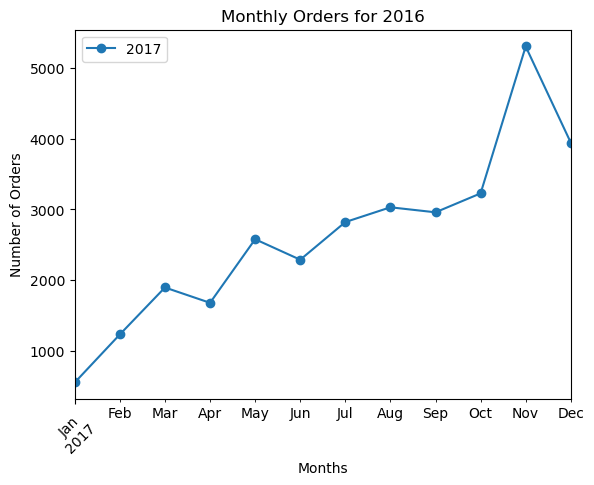

In [34]:
df_2017.set_index('order_purchase_timestamp').resample('M')['order_id'].count().plot(kind='line', marker='o', label='2017')

plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders for 2016')
plt.legend()
plt.xticks(rotation=45)
plt.show()

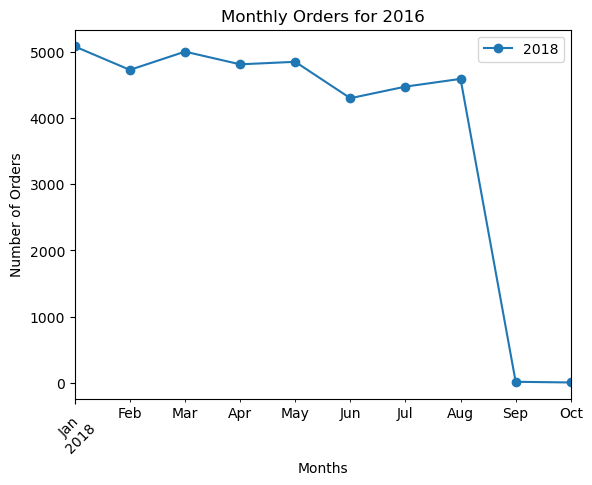

In [35]:
df_2018.set_index('order_purchase_timestamp').resample('M')['order_id'].count().plot(kind='line', marker='o', label='2018')

plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders for 2016')
plt.legend()
plt.xticks(rotation=45)
plt.show()

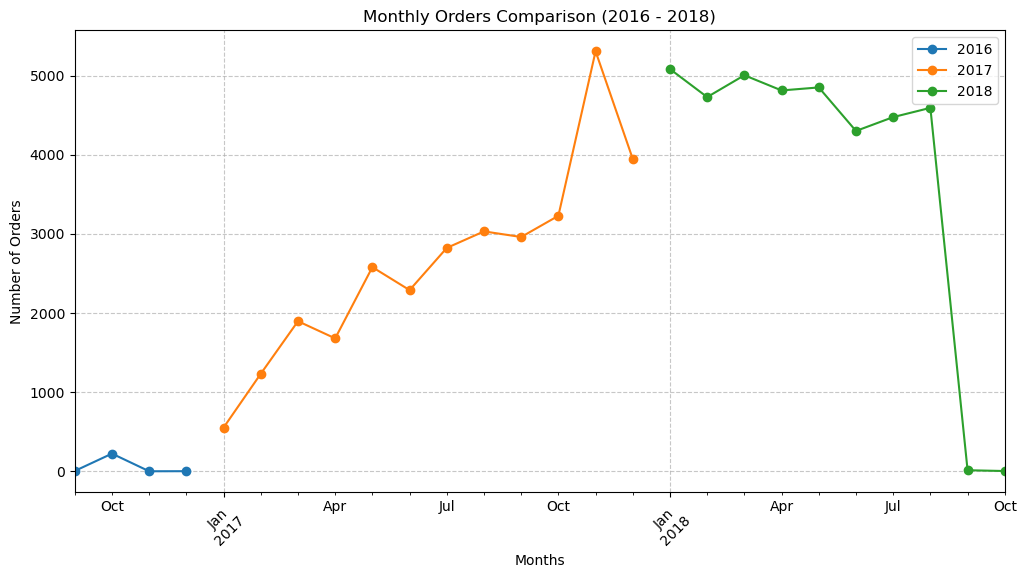

In [36]:
plt.figure(figsize=(12, 6))

# حلقة تكرارية لرسم السنين الثلاثة معاً
for year in [2016, 2017, 2018]:
    df_year = df[df['order_purchase_timestamp'].dt.year == year]
    df_year.set_index('order_purchase_timestamp').resample('M')['order_id'].count().plot(kind='line', marker='o', label=str(year))

plt.xlabel('Months')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders Comparison (2016 - 2018)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7) # إضافة خطوط شبكية لتسهيل القراءة
plt.xticks(rotation=45)
plt.show()

تظهر موسمية خفيفة (مثل ارتفاع الطلبات في نوفمبر)، لكنها غير متكررة بانتظام.

السبب: عدم اكتمال البيانات الزمنية للسنين (سنة 2017 وحدها هي الكاملة، بينما 2016 و2018 غير مكتملتين).

In [37]:
# 1. استخراج اسم اليوم (مثل Monday, Tuesday, ...)
df['order_day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# 2. استخراج رقم اليوم بترتيب الأسبوع (0 = الاثنين، 6 = الأحد) لضمان الترتيب الصحيح
df['order_day_num'] = df['order_purchase_timestamp'].dt.dayofweek

# 3. تجميع الطلبات حسب اليوم وحساب عدد الطلبات أو نسبة التأخير
daily_analysis = df.groupby(['order_day_num', 'order_day_of_week']).agg(
    total_orders=('order_id', 'count'),
    late_rate=('is_late', 'mean')
).reset_index().sort_values('order_day_num')

print(daily_analysis)

   order_day_num order_day_of_week  total_orders  late_rate
0              0            Monday         11314   0.085646
1              1           Tuesday         11165   0.082311
2              2         Wednesday         10874   0.075961
3              3          Thursday         10343   0.072996
4              4            Friday          9904   0.080775
5              5          Saturday          7587   0.073679
6              6            Sunday          8421   0.070775


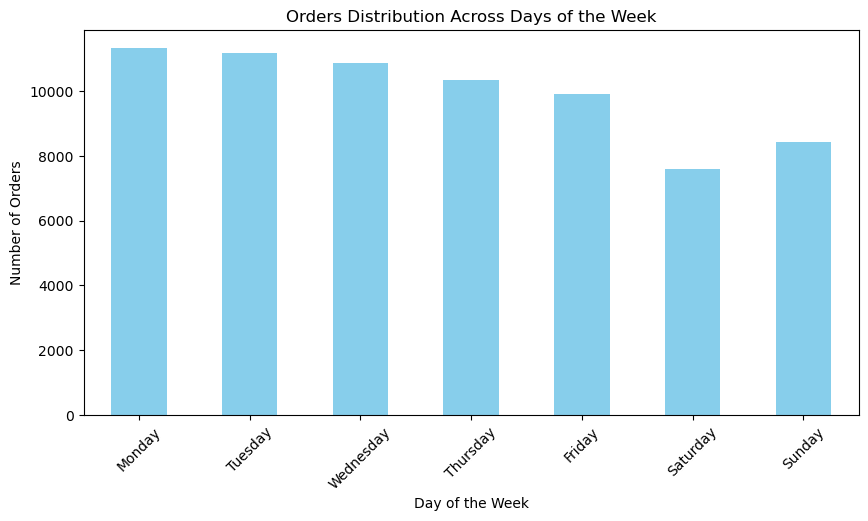

In [38]:

import matplotlib.pyplot as plt
import seaborn as plt_sns # أو استخدام المعتاد لديك

plt.figure(figsize=(10, 5))
# ترتيب الأيام تصاعدياً حسب الرقم عشان ما يلخبطوا
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby('order_day_of_week')['order_id'].count().reindex(day_order).plot(kind='bar', color='skyblue')

plt.title('Orders Distribution Across Days of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()


الزبائن بفضلوا التسوق الإلكتروني بكثرة خلال أيام العمل الرسمية، وبقل طلبهم بشكل ملحوظ في عطلة نهاية الأسبوع (خصوصاً السبت)

In [39]:
df.skew(numeric_only=True)

total_price                    10.923397
total_freight                  13.960589
total_items                     6.558802
total_weight_g                  6.291174
total_payment                  10.236173
max_installments                1.612719
review_score                   -1.361531
customer_zip_code_prefix        0.779951
geolocation_zip_code_prefix     0.786924
geolocation_lat                 1.653881
geolocation_lng                 0.021554
is_late                         3.149328
order_year                     -0.239311
order_day_num                   0.166761
dtype: float64

In [40]:
skewness = df.skew(numeric_only=True)
print(skewness.sort_values(ascending=False))

total_freight                  13.960589
total_price                    10.923397
total_payment                  10.236173
total_items                     6.558802
total_weight_g                  6.291174
is_late                         3.149328
geolocation_lat                 1.653881
max_installments                1.612719
geolocation_zip_code_prefix     0.786924
customer_zip_code_prefix        0.779951
order_day_num                   0.166761
geolocation_lng                 0.021554
order_year                     -0.239311
review_score                   -1.361531
dtype: float64


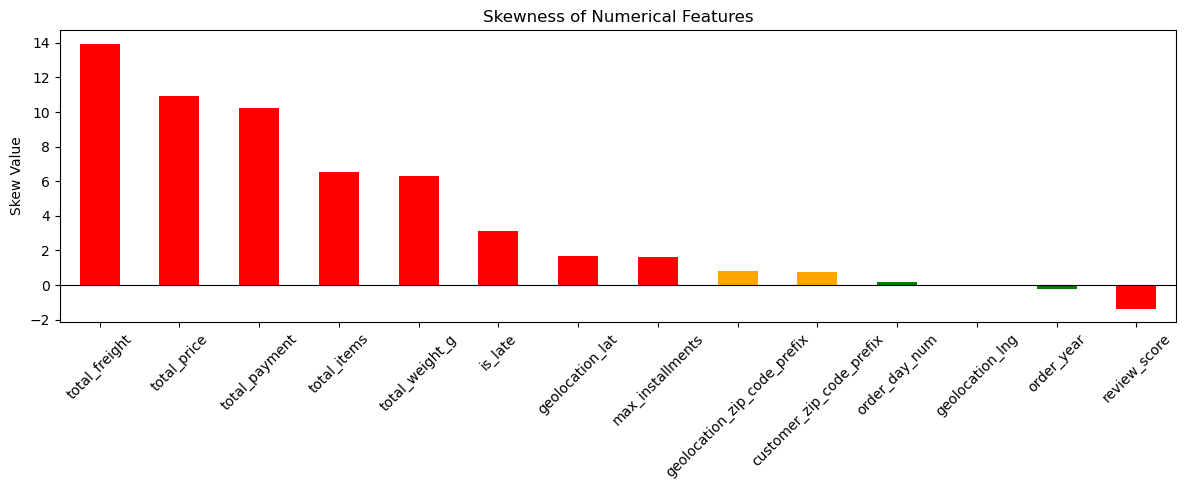

In [41]:
import matplotlib.pyplot as plt

skewness = df.skew(numeric_only=True).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = ['red' if abs(v) > 1 else 'orange' if abs(v) > 0.5 else 'green' for v in skewness]
skewness.plot(kind='bar', color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Skewness of Numerical Features')
plt.ylabel('Skew Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
corr = df.corr(numeric_only=True)
corr

,total_price,total_freight,total_items,total_weight_g,total_payment,max_installments,review_score,customer_zip_code_prefix,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,is_late,order_year,order_day_num
total_price,1.000000,0.402315,0.151099,0.345400,0.995973,0.313014,-0.043584,0.043844,0.044137,0.050145,0.015240,0.012325,-0.003608,0.000356
total_freight,0.402315,1.000000,0.430143,0.640718,0.482643,0.194629,-0.085036,0.188343,0.188661,0.217913,0.071980,0.021983,0.025229,0.000672
total_items,0.151099,0.430143,1.000000,0.219901,0.186670,0.065211,-0.113129,0.000564,0.000823,-0.013951,-0.013655,-0.014606,-0.001237,-0.010435
total_weight_g,0.345400,0.640718,0.219901,1.000000,0.393068,0.189662,-0.054226,0.004545,0.004752,0.000401,-0.001509,0.014508,-0.024105,-0.004147
total_payment,0.995973,0.482643,0.186670,0.393068,1.000000,0.317730,-0.052244,0.059933,0.060262,0.068498,0.021136,0.013268,-0.001173,0.000209
max_installments,0.313014,0.194629,0.065211,0.189662,0.317730,1.000000,-0.030638,0.055621,0.056063,0.062035,0.039184,0.006337,-0.062170,0.027068
review_score,-0.043584,-0.085036,-0.113129,-0.054226,-0.052244,-0.030638,1.000000,-0.015155,-0.015260,-0.038721,-0.046946,-0.323444,0.003460,-0.008110
customer_zip_code_prefix,0.043844,0.188343,0.000564,0.004545,0.059933,0.055621,-0.015155,1.000000,1.000000,0.124033,-0.303370,0.026458,-0.036113,0.001782
geolocation_zip_code_prefix,0.044137,0.188661,0.000823,0.004752,0.060262,0.056063,-0.015260,1.000000,1.000000,0.124033,-0.303370,0.026558,-0.036577,0.001827
geolocation_lat,0.050145,0.217913,-0.013951,0.000401,0.068498,0.062035,-0.038721,0.124033,0.124033,1.000000,0.453407,0.054414,-0.020880,0.011563


<Axes: >

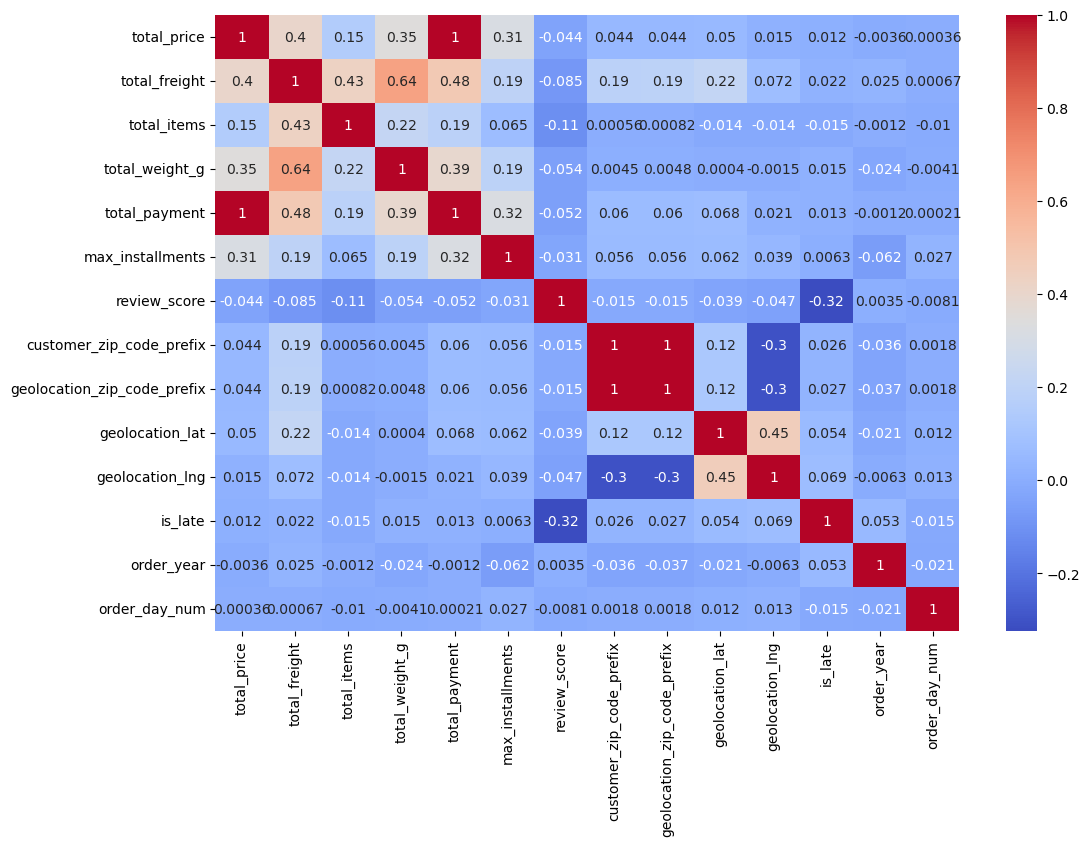

In [43]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True)

In [44]:
help(sns.heatmap)

Help on function heatmap in module seaborn.matrix:

heatmap(data, *, vmin=None, vmax=None, cmap=None, center=None, robust=False, annot=None, fmt='.2g', annot_kws=None, linewidths=0, linecolor='white', cbar=True, cbar_kws=None, cbar_ax=None, square=False, xticklabels='auto', yticklabels='auto', mask=None, ax=None, **kwargs)
    Plot rectangular data as a color-encoded matrix.
    
    This is an Axes-level function and will draw the heatmap into the
    currently-active Axes if none is provided to the ``ax`` argument.  Part of
    this Axes space will be taken and used to plot a colormap, unless ``cbar``
    is False or a separate Axes is provided to ``cbar_ax``.
    
    Parameters
    ----------
    data : rectangular dataset
        2D dataset that can be coerced into an ndarray. If a Pandas DataFrame
        is provided, the index/column information will be used to label the
        columns and rows.
    vmin, vmax : floats, optional
        Values to anchor the colormap, otherwise 

In [45]:
pd.set_option('display.max_rows', None)


In [46]:
column_name = 'product_category_name' # مثال

# اختيار الأعمدة النصية/التصنيفية واستثناء أي عمود يحتوي على 'id'
categorical_cols = [
    col for col in df.select_dtypes(include=['object', 'category']).columns 
    if 'id' not in col.lower()
]

# حلقة لاستعراض أندر القيم لكل عمود تصنيفي صالح
for column_name in categorical_cols:
    counts = df[column_name].value_counts()
    percentages = df[column_name].value_counts(normalize=True) * 100

    rare_check = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    
    print(f"=== column:: {column_name} ===")
    print(rare_check.head(10))
    print("\n" + "="*40 + "\n")

=== column:: order_status ===
              Count  Percentage (%)
order_status                       
delivered     67532       97.017584
shipped         793        1.139237
canceled        443        0.636421
unavailable     419        0.601942
processing      208        0.298816
invoiced        207        0.297380
created           5        0.007183
approved          1        0.001437


=== column:: main_category ===
                       Count  Percentage (%)
main_category                               
bed_bath_table          6516        9.570249
health_beauty           6151        9.034163
sports_leisure          5430        7.975208
computers_accessories   4640        6.814911
furniture_decor         4424        6.497665
housewares              4115        6.043827
watches_gifts           3917        5.753018
telephony               2958        4.344505
auto                    2759        4.052228
toys                    2676        3.930323


=== column:: seller_state ===
     

In [47]:
# الأعمدة التصنيفية (مع استثناء ID والنص الحر)
categorical_cols = [
    col for col in df.select_dtypes(include='object').columns
    if 'id' not in col.lower() 
    and 'comment' not in col.lower()
    and 'timestamp' not in col.lower()
]

print("الأعمدة التصنيفية:", categorical_cols)

الأعمدة التصنيفية: ['order_status', 'main_category', 'seller_state', 'review_creation_date', 'customer_city', 'customer_state', 'geolocation_city', 'geolocation_state', 'order_day_of_week']


In [48]:
threshold = 0.01  # 1%

for col in categorical_cols:
    freq = df[col].value_counts(normalize=True)  # النسبة المئوية
    rare = freq[freq < threshold]
    
    if len(rare) > 0:
        print(f"\n🔴 [{col}] — فيه {len(rare)} فئة نادرة من أصل {freq.shape[0]}:")
        print(rare.round(4))
    else:
        print(f"\n✅ [{col}] — لا يوجد فئات نادرة")


🔴 [order_status] — فيه 6 فئة نادرة من أصل 8:
order_status
canceled       0.0064
unavailable    0.0060
processing     0.0030
invoiced       0.0030
created        0.0001
approved       0.0000
Name: proportion, dtype: float64

🔴 [main_category] — فيه 50 فئة نادرة من أصل 71:
main_category
home_appliances                            0.0079
construction_tools_construction            0.0073
small_appliances                           0.0066
musical_instruments                        0.0065
books_general_interest                     0.0054
home_construction                          0.0048
food                                       0.0047
furniture_living_room                      0.0043
home_confort                               0.0041
audio                                      0.0034
drinks                                     0.0031
market_place                               0.0029
books_technical                            0.0026
kitchen_dining_laundry_garden_furniture    0.0025
industry_comm

In [49]:
# شوف التوزيع الكامل
freq = df['main_category'].value_counts()
freq_pct = df['main_category'].value_counts(normalize=True) * 100

pd.DataFrame({'count': freq, 'percentage': freq_pct.round(2)})

,count,percentage
main_category,,
bed_bath_table,6516,9.57
health_beauty,6151,9.03
sports_leisure,5430,7.98
computers_accessories,4640,6.81
furniture_decor,4424,6.50
housewares,4115,6.04
watches_gifts,3917,5.75
telephony,2958,4.34
auto,2759,4.05


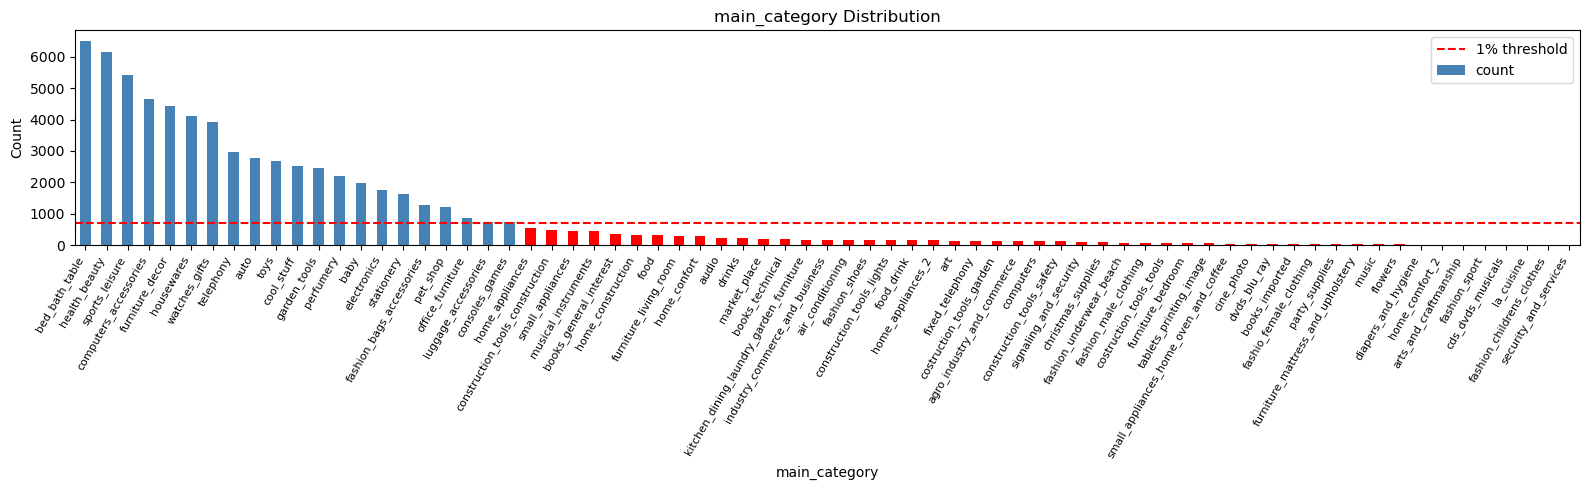


إجمالي الفئات: 71
فئات نادرة (< 1%): 50
فئات كبيرة (>= 1%): 21


In [50]:
import matplotlib.pyplot as plt

freq = df['main_category'].value_counts()

plt.figure(figsize=(16, 5))
freq.plot(kind='bar', color=['steelblue' if v/len(df) > 0.01 else 'red' for v in freq])
plt.axhline(len(df) * 0.01, color='red', linestyle='--', label='1% threshold')
plt.title('main_category Distribution')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nإجمالي الفئات: {freq.shape[0]}")
print(f"فئات نادرة (< 1%): {(freq/len(df) < 0.01).sum()}")
print(f"فئات كبيرة (>= 1%): {(freq/len(df) >= 0.01).sum()}")